# 03. Primera pregunta: ¿cuánto y dónde ha crecido la participación femenina?

Primera de las cuatro preguntas de análisis. Aquí se describe el fenómeno: cuánta
gente compite, desde cuándo, dónde, y a qué ritmo ha cambiado.

Antes de cualquier modelo o contraste, conviene entender la forma de los datos.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
import numpy as np
from IPython.display import Image, display

import config as cfg
import estilo
import analisis

estilo.aplicar()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

df = analisis.cargar()


CARGA DEL CONJUNTO FINAL


  825,296 filas x 83 columnas   (dataset_final_powerlifting_femenino.csv)


## Panorama general

Primer contacto con el conjunto final: volumen, cobertura y forma de las
distribuciones de rendimiento.

In [2]:
analisis.a1_panorama(df)


A1. PANORAMA GENERAL
  n_registros                  825296
  n_atletas                    227570
  n_paises                     114
  n_federaciones               400
  n_competiciones              24041
  periodo                      ['1975-09-05', '2026-08-09']
  competiciones_por_atleta     3.63

  Descriptivos de las variables de rendimiento:


                     count    mean    std    min     25%     50%     75%     max
total_kg          825296.0  303.90  82.32  34.00  247.21  297.10  352.50  932.50
peso_corporal_kg  825296.0   69.15  18.15  30.00   56.00   65.90   78.02  216.00
fuerza_relativa   825296.0    4.53   1.23   0.59    3.67    4.44    5.29   11.81
puntos_dots       825296.0  317.03  77.13  46.83  263.49  311.04  363.54  818.06
kg_sentadilla     825296.0  114.30  35.08   2.27   90.00  111.13  135.00  432.50
kg_banca          825296.0   62.13  20.92   4.54   47.63   60.00   72.50  283.50
kg_peso_muerto    825296.0  127.48  31.55   1.00  105.00  125.00  147.50  315.00
edad              474759.0   29.16  11.99  10.00   20.00   26.00   36.00   90.00

  Forma de las distribuciones:
    total_kg           asimetria=+0.631  curtosis=+0.948
    fuerza_relativa    asimetria=+0.505  curtosis=+0.473
    puntos_dots        asimetria=+0.537  curtosis=+0.693



  [figura] a1_distribuciones_rendimiento.png


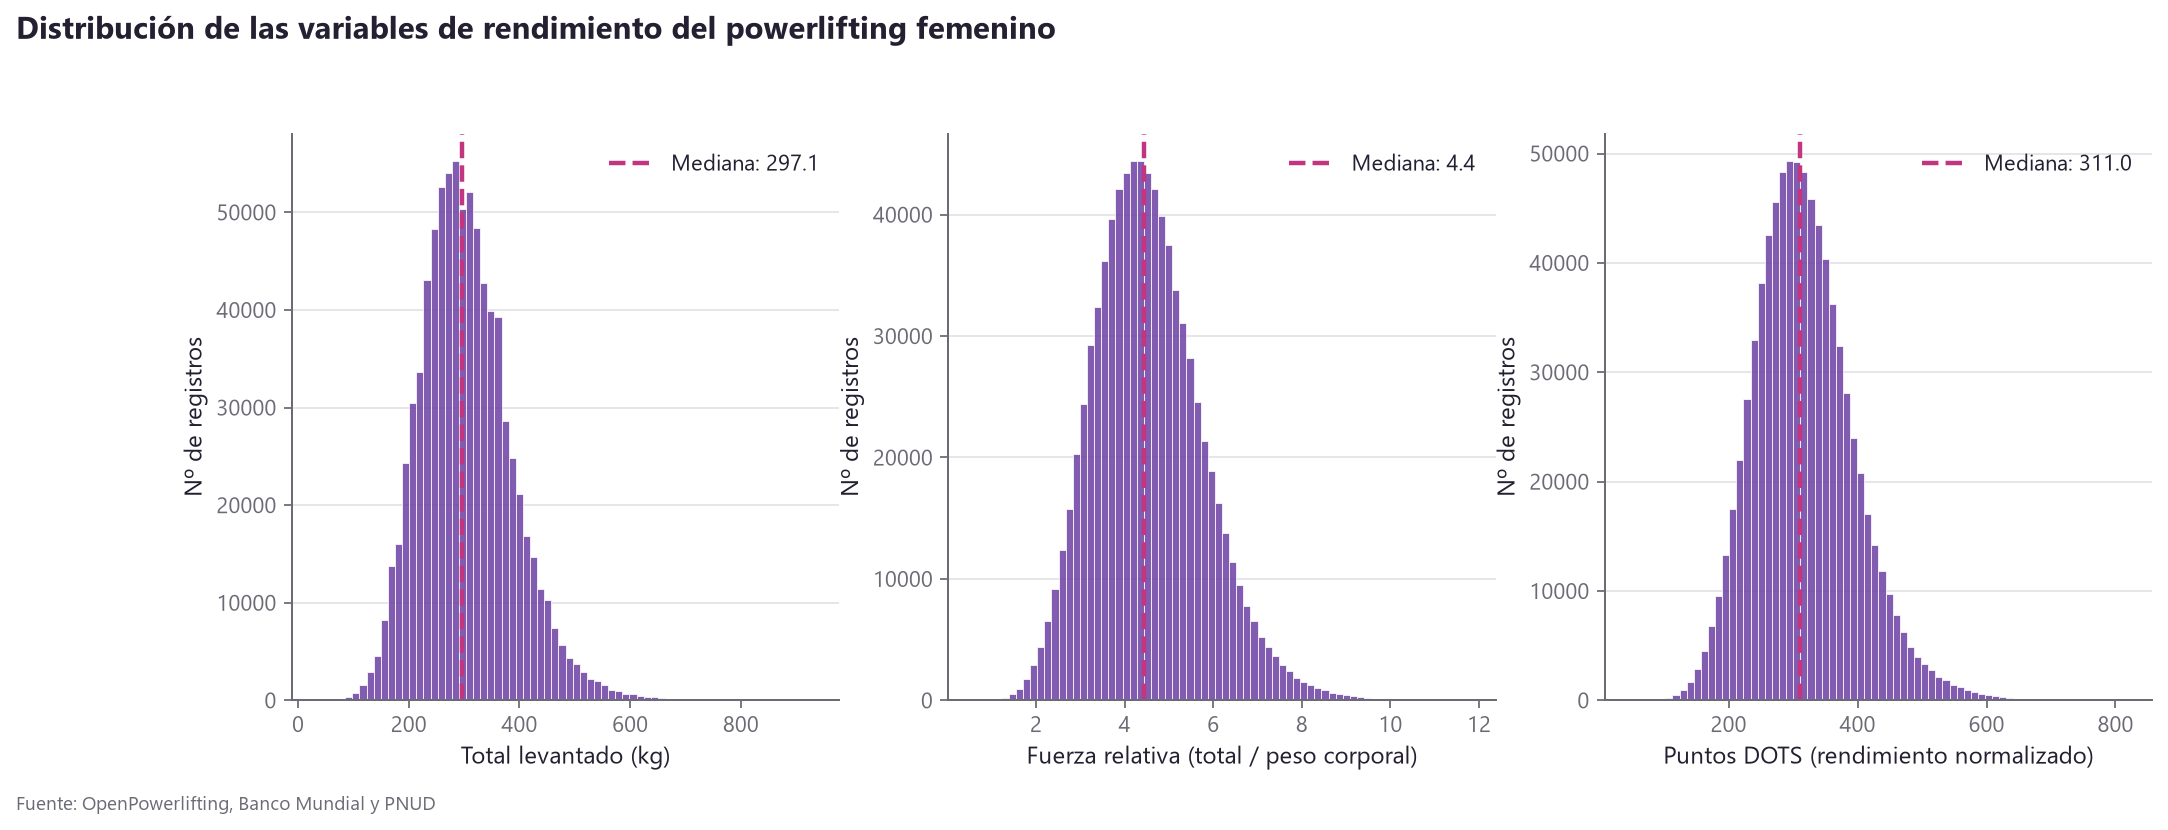

In [3]:
display(Image(filename=str(cfg.FIGURES / "a1_distribuciones_rendimiento.png")))

### Por qué esto ya condiciona el análisis

Las tres distribuciones presentan asimetría positiva, con una cola larga hacia los
valores altos. No es un defecto de los datos, es la forma natural del rendimiento
deportivo: muchas atletas en niveles intermedios y unas pocas de élite muy por
encima.

La consecuencia metodológica es directa. Se usará la mediana en lugar de la media
para describir el nivel típico, y pruebas no paramétricas como Mann-Whitney o
Kruskal-Wallis junto a las paramétricas, porque no se puede asumir normalidad.

## El crecimiento en el tiempo

In [4]:
analisis.a2_evolucion(df)


A2. EVOLUCION TEMPORAL DE LA PARTICIPACION FEMENINA
 anio  registros  atletas  total_mediano  dots_mediano  pct_femenina
 2011       5519     3383         305.00       331.110     13.728442
 2012       6541     3980         295.00       319.230     14.397918
 2013       9673     5940         287.50       311.900     15.972426
 2014      29878    13915         270.00       290.970     28.761500
 2015      38748    18538         278.00       296.470     31.150601
 2016      46098    23019         283.50       301.370     32.345018
 2017      51949    26605         290.00       305.290     33.805044
 2018      56616    28892         292.50       307.170     34.640696
 2019      60644    31521         295.00       309.580     34.939670
 2020      36814    19247         288.03       301.945     36.915041
 2021      44570    24387         300.00       311.600     34.746831
 2022      67405    33284         300.00       311.010     36.873569
 2023      79871    40403         302.50       313

  Cuota femenina 2000: 25.1%   2025: 37.4%
  Tendencia: +0.898 puntos porcentuales/anio (R2=0.610, p=2.47e-06)
  [figura] a2_evolucion_participacion.png


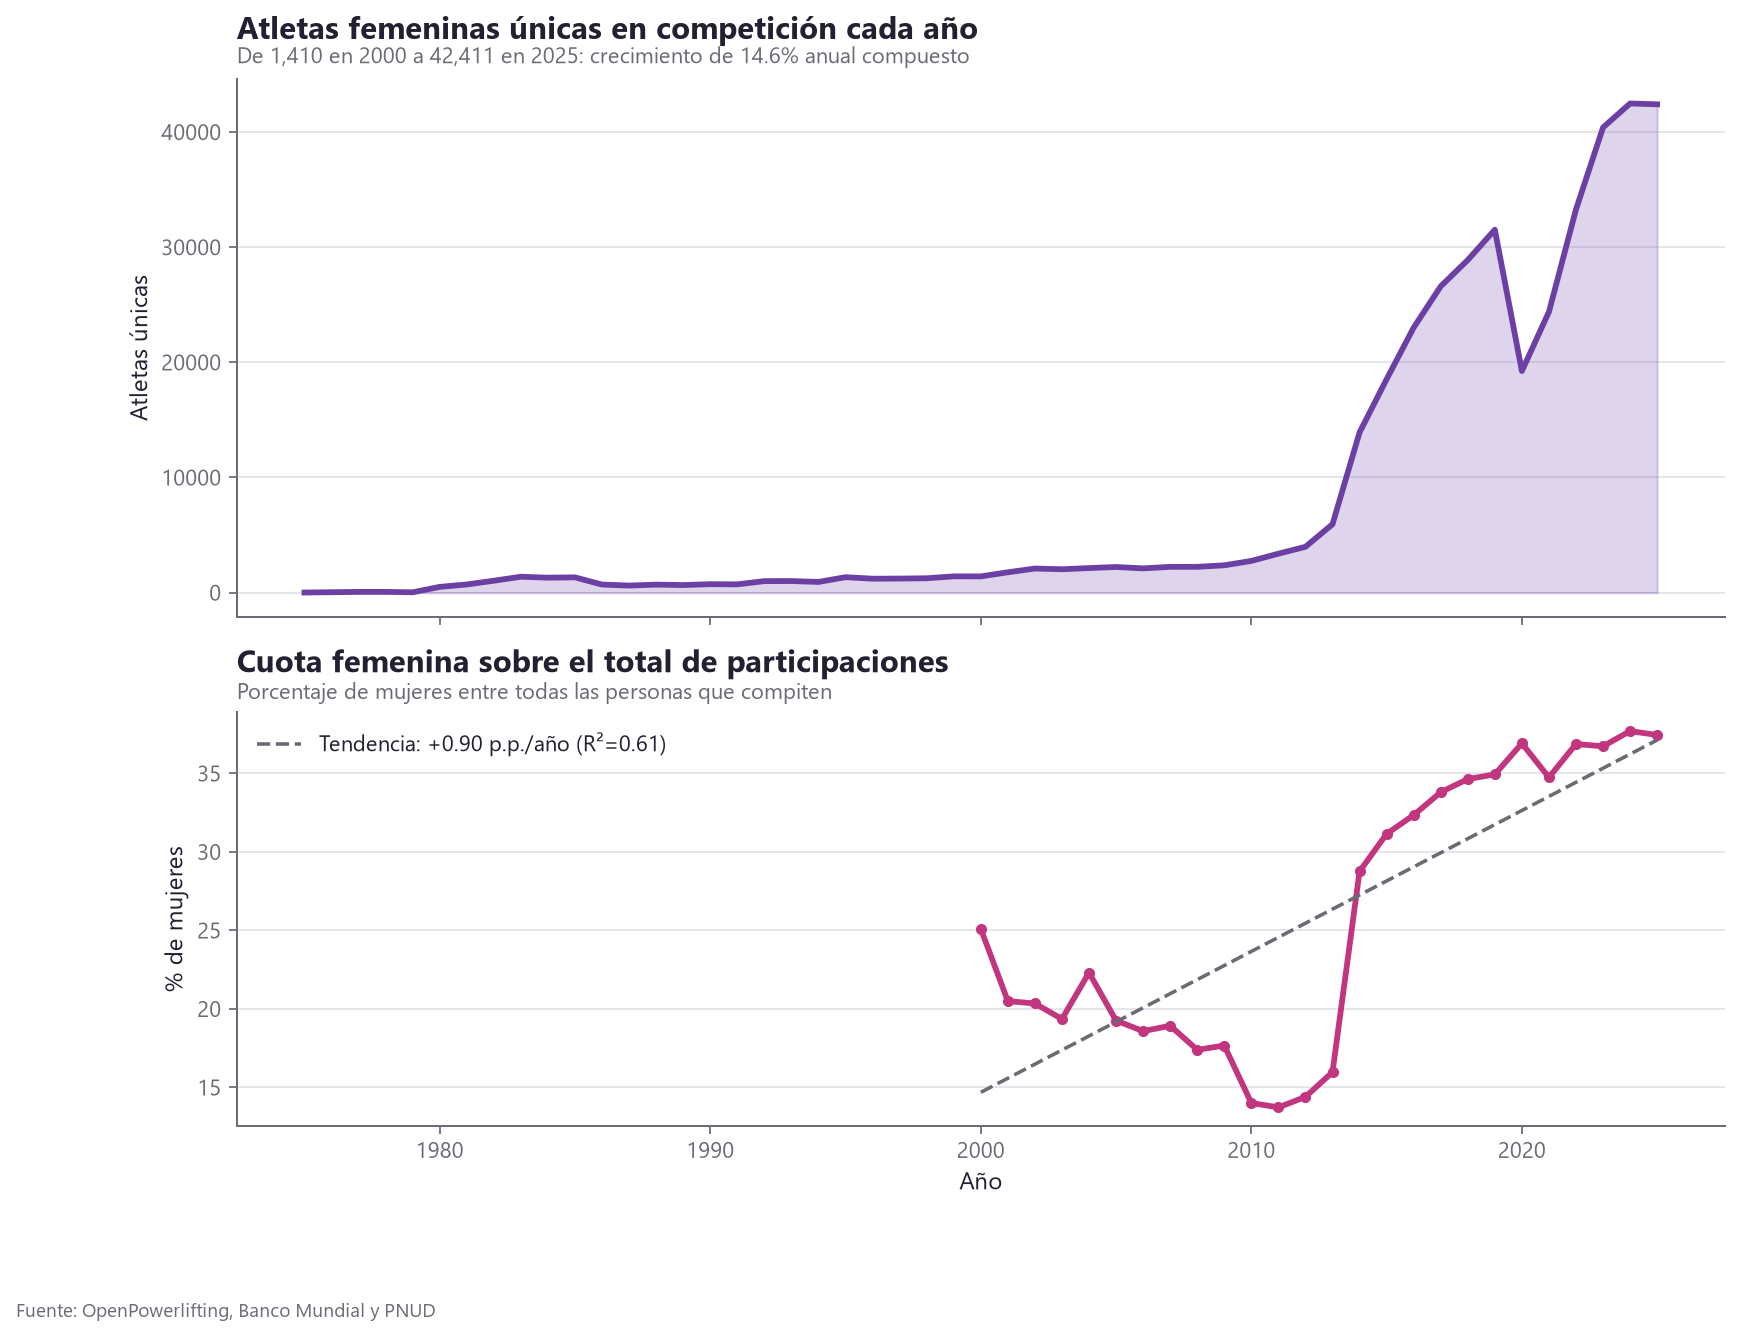

In [5]:
display(Image(filename=str(cfg.FIGURES / "a2_evolucion_participacion.png")))

Dos resultados responden a esta primera pregunta.

El primero es el crecimiento del volumen, que resulta explosivo: de 1.410 atletas
únicas en 2000 a más de 42.000 en 2025. Multiplicarse por 30 en 25 años equivale a
un crecimiento anual compuesto de casi el 15%.

El segundo es que no solo crece el deporte, sino que crece más la parte femenina. La
cuota de mujeres sobre el total de participaciones pasa del 17% al 36%, con una
tendencia estadísticamente sólida de 1,0 puntos porcentuales al año.

La distinción importa. El primer dato podría explicarse simplemente porque
OpenPowerlifting ha ido recopilando más competiciones con el tiempo. El segundo no,
porque es una proporción y por tanto inmune a que crezca la cobertura de la base de
datos. Es la evidencia sólida de que el powerlifting femenino gana peso real.

El bache de 2020 corresponde a la pandemia, no a un problema de datos.

## La distribución geográfica

In [6]:
analisis.a3_geografia(df)


A3. DISTRIBUCION GEOGRAFICA


  TOP 15 PAISES POR NUMERO DE ATLETAS:
pais_competicion            region  atletas  total_mediano  dots_mediano  cuota_femenina
             USA America del Norte   139820          287.5       298.680       36.307886
          Russia            Europa    14229          287.5       327.920       20.963816
          Canada America del Norte     9203          315.0       324.690       34.352467
       Australia           Oceania     8232          325.0       334.330       36.392943
         England            Europa     7345          312.5       323.730       32.824041
              UK            Europa     3772          320.0       336.400       34.412867
          France            Europa     3742          317.5       346.000       28.606248
           India              Asia     3472          300.0       327.035       34.066241
         Ukraine            Europa     3403          285.0       325.630       20.921597
         Germany            Europa     3029          332.5       347.11


  POR REGION:
                         atletas  registros  dots_mediano  cuota_femenina
region                                                                   
America del Norte         149090     565205        300.03           36.19
Europa                     54962     187891        338.56           27.38
Asia                       12344      23063        327.75           29.10
Oceania                    10418      32783        331.80           36.39
America Latina y Caribe     6384      12240        347.74           30.61
Africa                      2406       4114        347.38           34.16


  [figura] a3_geografia.png


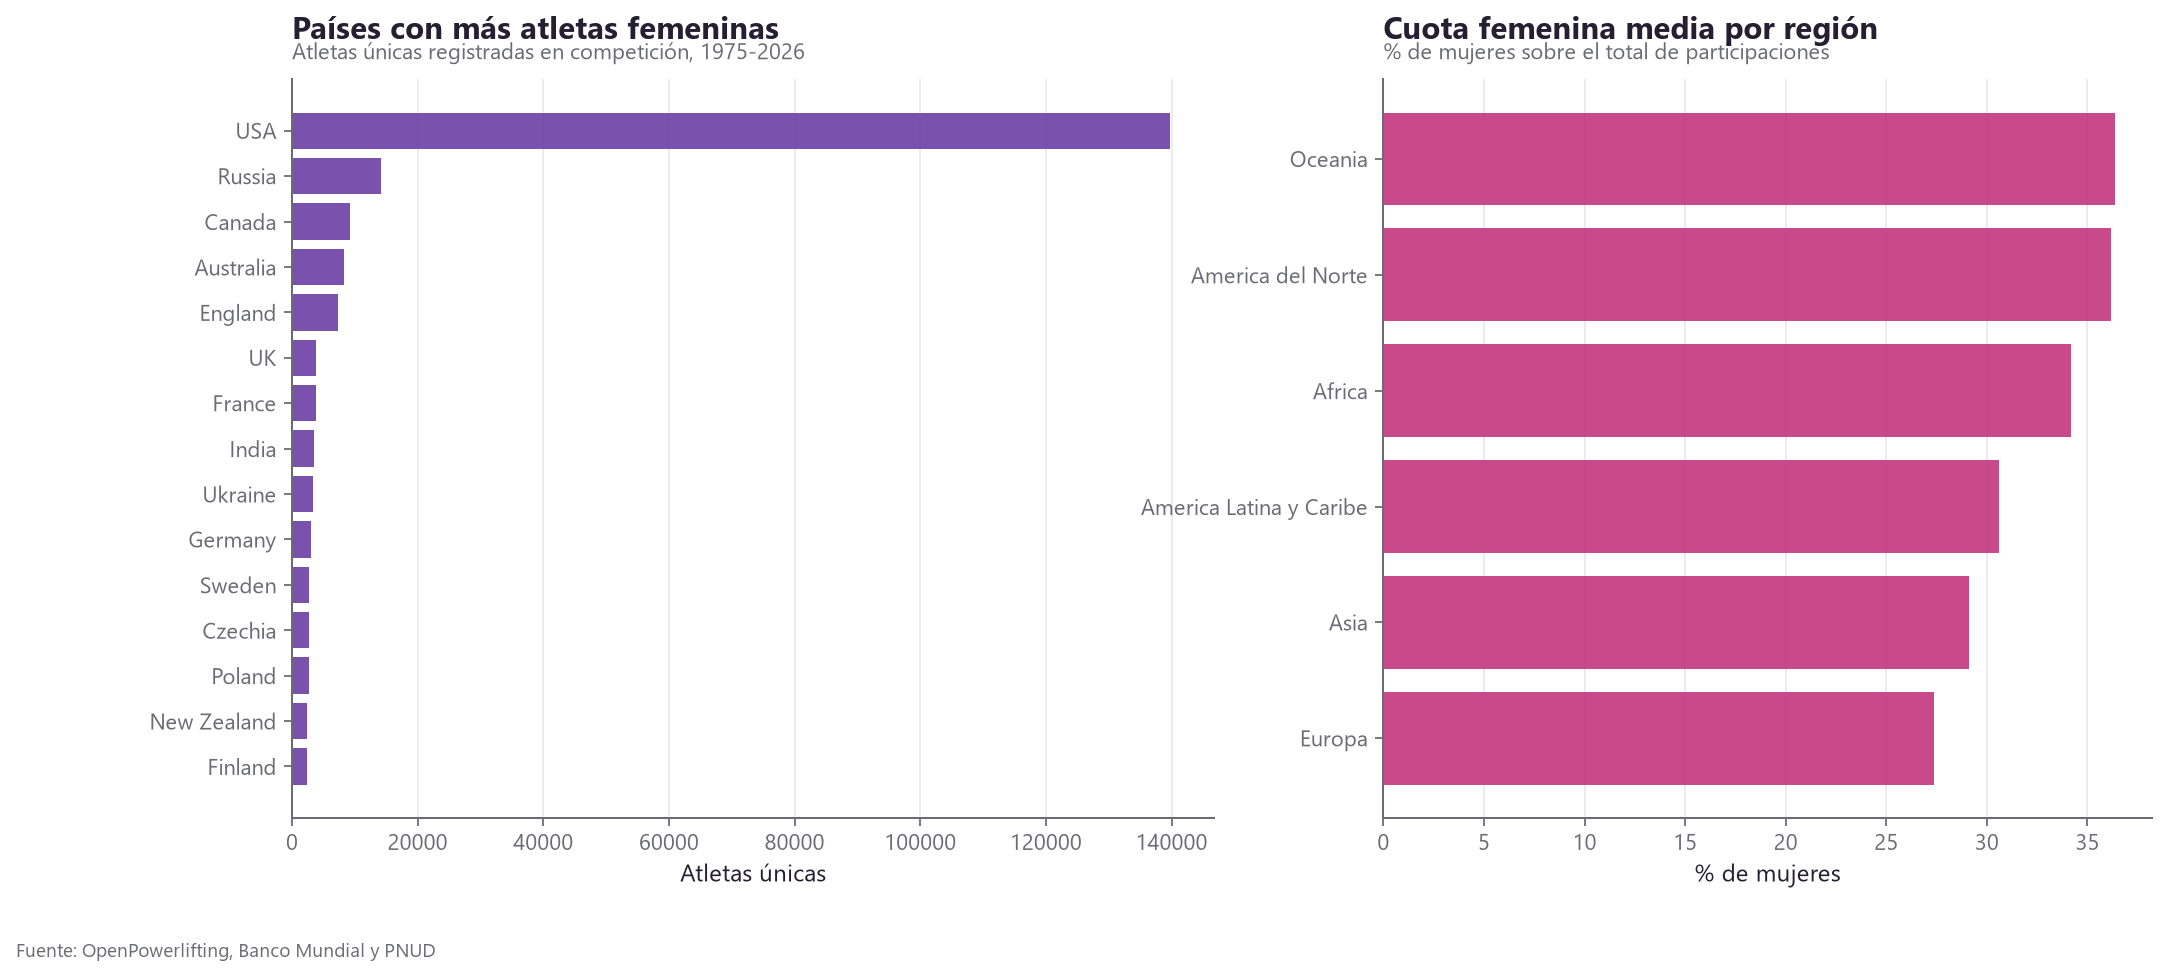

In [7]:
display(Image(filename=str(cfg.FIGURES / "a3_geografia.png")))

### El sesgo que condiciona todo el proyecto

Aquí aparece el hallazgo metodológico más importante del análisis: Estados Unidos
concentra alrededor del 68% de los registros, y los cinco primeros países casi el
70% de las atletas.

Esto significa que cualquier estadística "mundial" calculada sin más es, en
realidad, una estadística sobre Estados Unidos.

Tal como se fijó en el plan del proyecto, la respuesta no es ocultarlo ni
eliminarlo, sino separar dos niveles de lectura que se mantienen en todo el trabajo.
El nivel global usa todos los datos, advirtiendo siempre de que refleja sobre todo
la realidad estadounidense. El nivel comparado internacional se restringe a los
países con volumen suficiente, y es el único válido para afirmar algo sobre
diferencias entre países; es el que se usa en la tercera pregunta.

In [8]:
# Cuanto pesa cada pais: el sesgo, cuantificado
peso = (df["pais_competicion"].value_counts(normalize=True) * 100).round(2)
print("Peso de cada pais en el conjunto (%):")
print(peso.head(10).to_string())
print(f"\nAcumulado top 5: {peso.head(5).sum():.1f}%")
print(f"Acumulado top 10: {peso.head(10).sum():.1f}%")
print(f"\nPaises que aportan menos del 0,5% cada uno: {(peso < 0.5).sum()} de {len(peso)}")

Peso de cada pais en el conjunto (%):
pais_competicion
USA          65.08
Russia        5.20
Canada        3.17
Australia     3.09
England       2.40
Norway        1.20
France        1.19
Ukraine       1.11
Germany       0.99
Finland       0.92

Acumulado top 5: 78.9%
Acumulado top 10: 84.4%

Paises que aportan menos del 0,5% cada uno: 100 de 120


In [9]:
# Nivel B: que paises son comparables? Los que tienen volumen suficiente
volumen = df.groupby(["iso3", "pais_competicion"]).size().rename("registros").reset_index()
comparables = volumen[volumen["registros"] >= 2000].sort_values("registros", ascending=False)
print(f"Paises con 2.000+ registros (aptos para comparacion): {len(comparables)}")
print(comparables.head(20).to_string(index=False))

Paises con 2.000+ registros (aptos para comparacion): 32
iso3 pais_competicion  registros
 USA              USA     537100
 RUS           Russia      42889
 CAN           Canada      26169
 AUS        Australia      25495
 GBR          England      19777
 NOR           Norway       9923
 FRA           France       9858
 UKR          Ukraine       9121
 DEU          Germany       8138
 FIN          Finland       7578
 SWE           Sweden       7426
 GBR               UK       7161
 NZL      New Zealand       7052
 CZE          Czechia       6486
 POL           Poland       6458
 IND            India       5842
 ITA            Italy       5635
 IRL          Ireland       5256
 ESP            Spain       4856
 ARG        Argentina       4119


## Síntesis de la primera pregunta

El powerlifting femenino crece con fuerza, multiplicando por 30 las atletas únicas
entre 2000 y 2025, con una tasa anual compuesta del 14,6%.

Además gana peso relativo dentro del deporte: la cuota femenina pasa del 17% al 36%,
con una tendencia de 1,0 puntos porcentuales al año y un R² de 0,61.

Pero la muestra está muy concentrada, con Estados Unidos en torno al 68% de los
registros y los cinco primeros países acumulando cerca del 70% de las atletas.

El siguiente cuaderno, `04_pregunta2_rendimiento.ipynb`, aborda qué determina el
rendimiento.